# ChromSeek ChIA-PET Prediction Workflow

This notebook follows the ChromSeek Hi-C enhancement app pattern for predicting ChIA-PET interaction anchors from a 2.24 Mb DNA/Hi-C window. It will:

1. Configure the bundled sample and pretrained checkpoint.
2. Load and prepare DNA, Hi-C, and ChIA-PET labels.
3. Run the pretrained ChromSeek ChIA-PET model.
4. Compute AUC/F1/AP and visualize the Hi-C map, prediction, and ground truth.

In [1]:
# ==========================================
# 1. Configuration & Setup
# ==========================================
from pathlib import Path

for PROJECT_ROOT in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
    if (PROJECT_ROOT / 'hic_enhancement').is_dir() and (PROJECT_ROOT / 'downstreams').is_dir():
        break
else:
    raise FileNotFoundError('Could not locate the ChromSeek project root.')
TASK_DIR = PROJECT_ROOT / 'downstreams' / 'chiapet_prediction'

DATA_PATH = TASK_DIR / 'sample_data.pt'
CKPT_PATH = PROJECT_ROOT / 'checkpoints' / 'chromSeek_chiapet_prediction.pth'
PRED_THRESHOLD = 0.50
EXCLUDE_DIAGONAL_BINS = 1

if not DATA_PATH.exists():
    raise FileNotFoundError(f'Sample data not found: {DATA_PATH}')
if not CKPT_PATH.exists():
    raise FileNotFoundError(f'ChIA-PET checkpoint not found: {CKPT_PATH}')
print(f'Configured data: {DATA_PATH}')
print(f'Configured checkpoint: {CKPT_PATH}')
print(f'Prediction threshold: {PRED_THRESHOLD}')

Configured data: /home/common/qxzhang_zhuli/chromSeek/downstreams/chiapet_prediction/sample_data.pt
Configured checkpoint: /home/common/qxzhang_zhuli/chromSeek/checkpoints/chromSeek_chiapet_prediction.pth
Prediction threshold: 0.5


In [2]:
# ==========================================
# 2. Load Dependencies & Imports
# ==========================================
import sys
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import average_precision_score, f1_score, roc_auc_score

sys.path.insert(0, str(PROJECT_ROOT))
from downstreams.chiapet_prediction.model import ChromSeekChiapetModel

cuda_available = torch.cuda.is_available()
device = torch.device('cuda' if cuda_available else 'cpu')
print(f'Using device: {device}')
if not cuda_available:
    print('GPU is not visible to this Jupyter kernel; inference will run on CPU.')

Using device: cuda


In [3]:
# ==========================================
# 3. Load DNA, Hi-C & ChIA-PET Labels
# ==========================================
data = torch.load(DATA_PATH, map_location='cpu', weights_only=False)
required_keys = {'seq', 'hic', 'gt_chiapet', 'info'}
missing = required_keys.difference(data)
if missing:
    raise KeyError(f'Sample is missing required fields: {sorted(missing)}')

seq = data['seq'].float()
hic = data['hic'].float()
gt_chiapet = data['gt_chiapet'].squeeze().numpy().astype(np.float32)
hic_raw = np.asarray(data.get('hic_raw', hic.squeeze().numpy()))
info = data['info']
print(f'DNA tensor: {tuple(seq.shape)}')
print(f'Hi-C tensor: {tuple(hic.shape)}')
print(f'Ground-truth ChIA-PET map: {gt_chiapet.shape}; positive bins: {int(gt_chiapet.sum())}')
print('Region: {}:{}; cell: {}'.format(info.get('chrom', 'unknown'), info.get('start', 'unknown'), info.get('cell', 'unknown')))

DNA tensor: (4, 2240000)
Hi-C tensor: (1, 224, 224)
Ground-truth ChIA-PET map: (224, 224); positive bins: 16064
Region: chr18:0; cell: GM12878_Hic


In [4]:
# ==========================================
# 4. Preprocessing Data for Model
# ==========================================
t_seq = seq
if t_seq.ndim == 2:
    t_seq = t_seq.unsqueeze(0)
t_hic = hic
if t_hic.ndim == 3:
    t_hic = t_hic.unsqueeze(0)

# sample_data.pt was produced by the training pipeline and is already normalized.
t_seq = torch.nan_to_num(t_seq, nan=0.0, posinf=0.0, neginf=0.0).clamp(0, 1).to(device)
t_hic = torch.nan_to_num(t_hic, nan=0.0, posinf=0.0, neginf=0.0).clamp_min(0).to(device)
print(f'Model DNA input: {tuple(t_seq.shape)}')
print(f'Model Hi-C input: {tuple(t_hic.shape)}')

Model DNA input: (1, 4, 2240000)
Model Hi-C input: (1, 1, 224, 224)


In [5]:
# ==========================================
# 5. Load Pretrained ChIA-PET Model
# ==========================================
print('Building ChIA-PET model...', flush=True)
model = ChromSeekChiapetModel(pretrained_path=None).to(device)
print('Loading checkpoint...', flush=True)
state_dict = torch.load(CKPT_PATH, map_location='cpu', weights_only=True)
cleaned_state_dict = {
    (key[7:] if key.startswith('module.') else key): value
    for key, value in state_dict.items()
}
missing_keys, unexpected_keys = model.load_state_dict(cleaned_state_dict, strict=False)
model.eval()
print('ChIA-PET prediction model is ready.')
if missing_keys:
    print(f'Unloaded model keys: {len(missing_keys)}')
if unexpected_keys:
    print(f'Unused checkpoint keys: {len(unexpected_keys)}')

Building ChIA-PET model...
Loading checkpoint...
ChIA-PET prediction model is ready.


In [6]:
# ==========================================
# 6. Run ChIA-PET Inference
# ==========================================
print('Starting model inference; this may take a moment for the 2.24 Mb DNA window...', flush=True)
amp_enabled = device.type == 'cuda'
with torch.inference_mode():
    with torch.autocast(device_type=device.type, enabled=amp_enabled):
        pred_1d_logits, pred_2d_logits = model(t_seq, t_hic)
    pred_prob = torch.sigmoid(pred_2d_logits).squeeze().float().cpu().numpy()
    # The model returns (batch, task, bins); this workflow has one task.
    # Flatten it explicitly so plotting treats the output as one signal.
    pred_1d = torch.sigmoid(pred_1d_logits).float().cpu().numpy().reshape(-1)

if pred_prob.shape != gt_chiapet.shape:
    raise ValueError(f'Prediction/label shape mismatch: {pred_prob.shape} vs {gt_chiapet.shape}')
print(f'1D output shape: {pred_1d.shape}')
print(f'1D probability range: [{pred_1d.min():.4f}, {pred_1d.max():.4f}], mean={pred_1d.mean():.4f}, nonzero={np.count_nonzero(pred_1d)}/{pred_1d.size}')
print(f'2D probability map: {pred_prob.shape}')
print(f'Probability range: [{pred_prob.min():.4f}, {pred_prob.max():.4f}]')

Starting model inference; this may take a moment for the 2.24 Mb DNA window...
1D output shape: (1120,)
1D probability range: [0.3069, 0.7798], mean=0.5010, nonzero=1120/1120
2D probability map: (224, 224)
Probability range: [0.0015, 0.9995]


In [7]:
# ==========================================
# 7. Compute ChIA-PET Metrics
# ==========================================
mask = np.triu(np.ones_like(gt_chiapet, dtype=bool), k=EXCLUDE_DIAGONAL_BINS)
flat_true = gt_chiapet[mask].astype(int)
flat_pred = pred_prob[mask]
if np.unique(flat_true).size > 1:
    auc_value = roc_auc_score(flat_true, flat_pred)
    ap_value = average_precision_score(flat_true, flat_pred)
    f1_value = f1_score(flat_true, (flat_pred >= PRED_THRESHOLD).astype(int), zero_division=0)
else:
    auc_value = ap_value = f1_value = 0.0
print(f'ChIA-PET AUROC: {auc_value:.4f}')
print(f'ChIA-PET Average Precision: {ap_value:.4f}')
print(f'ChIA-PET F1 @ {PRED_THRESHOLD:.2f}: {f1_value:.4f}')

ChIA-PET AUROC: 0.8276
ChIA-PET Average Precision: 0.7261
ChIA-PET F1 @ 0.50: 0.6069


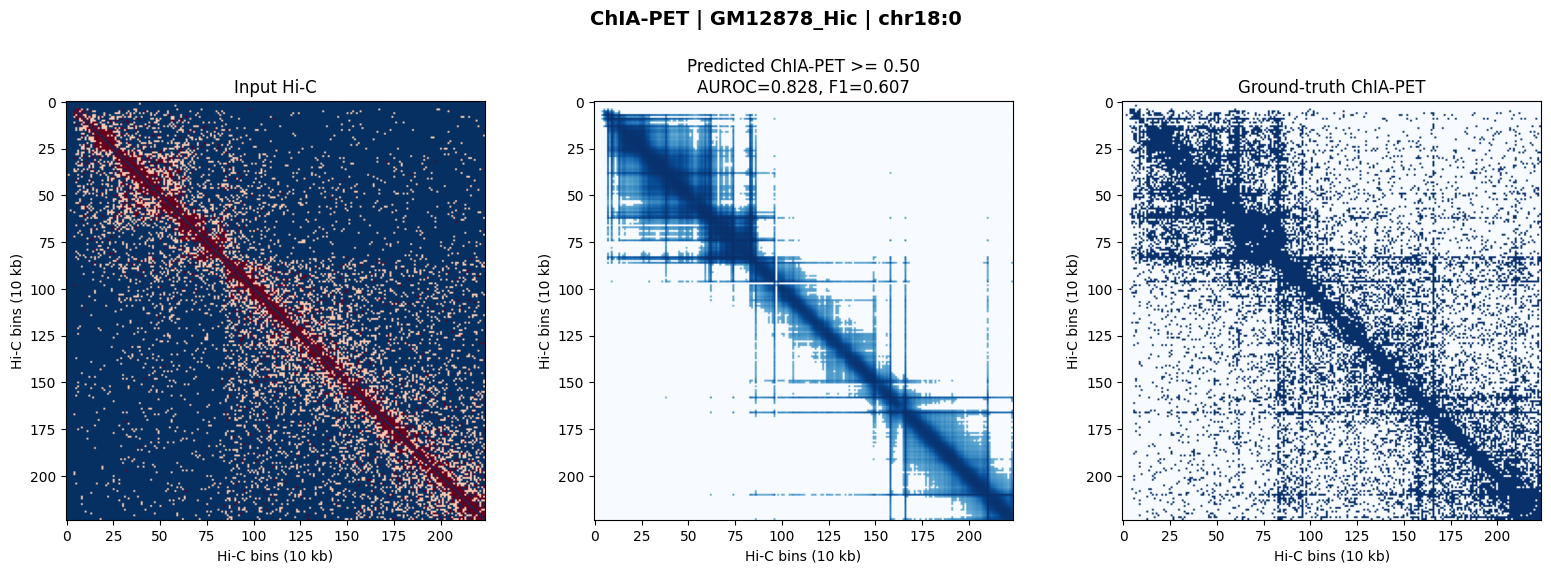

In [8]:
# ==========================================
# 8. Visualize Hi-C, Prediction & Ground Truth
# ==========================================
def display_hic(matrix):
    matrix = np.nan_to_num(matrix, nan=0.0, posinf=0.0, neginf=0.0).clip(min=0)
    logged = np.log1p(matrix)
    positive = logged[logged > 0]
    vmax = np.percentile(positive, 80) if positive.size else 1.0
    return logged, max(vmax, 1e-6)

hic_display, hic_vmax = display_hic(hic_raw)
pred_display = np.where(pred_prob >= PRED_THRESHOLD, pred_prob, 0)
gt_display = np.where(gt_chiapet >= 0.5, gt_chiapet, 0)
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
title = 'ChIA-PET | {} | {}:{}' .format(info.get('cell', 'unknown'), info.get('chrom', 'unknown'), info.get('start', 'unknown'))
fig.suptitle(title, fontsize=14, fontweight='bold')
axes[0].imshow(hic_display, cmap='RdBu_r', vmin=0, vmax=hic_vmax)
axes[0].set_title('Input Hi-C')
axes[1].imshow(pred_display, cmap='Blues', vmin=0, vmax=1)
axes[1].set_title(f'Predicted ChIA-PET >= {PRED_THRESHOLD:.2f}\nAUROC={auc_value:.3f}, F1={f1_value:.3f}')
axes[2].imshow(gt_display, cmap='Blues', vmin=0, vmax=1)
axes[2].set_title('Ground-truth ChIA-PET')
for ax in axes:
    ax.set_xlabel('Hi-C bins (10 kb)')
    ax.set_ylabel('Hi-C bins (10 kb)')
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

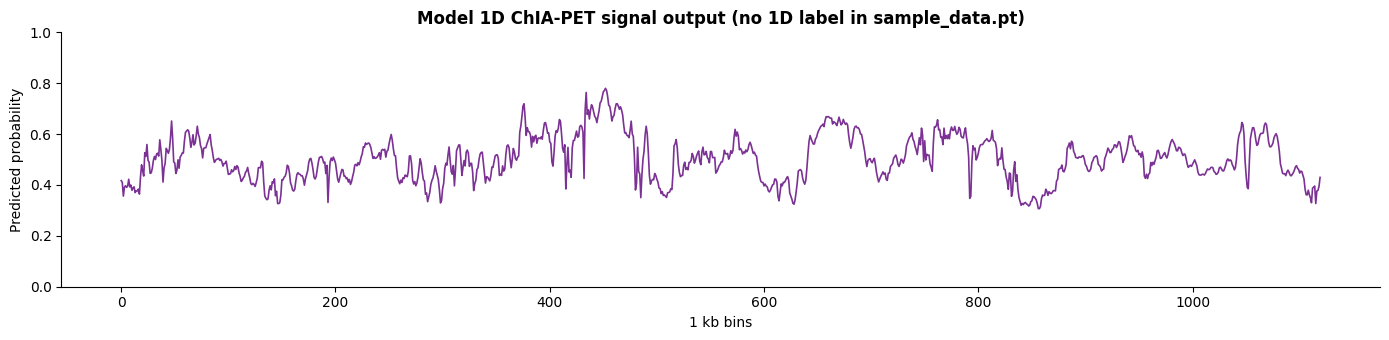

Workflow complete. Change PRED_THRESHOLD and rerun cells 7-9 to inspect another operating point.


In [9]:
# ==========================================
# 9. Optional: Inspect 1D Output
# ==========================================
fig, ax = plt.subplots(figsize=(14, 3.5))
ax.plot(np.arange(pred_1d.size), pred_1d, color='#7b3294', linewidth=1.2)
ax.set_title('Model 1D ChIA-PET signal output (no 1D label in sample_data.pt)', fontweight='bold')
ax.set_xlabel('1 kb bins')
ax.set_ylabel('Predicted probability')
ax.set_ylim(0, 1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print('Workflow complete. Change PRED_THRESHOLD and rerun cells 7-9 to inspect another operating point.')